# Cluster Then Reject: Variance-Based Post-Clustering Filtering

Cluster **all** test points once, then sort by uncertainty (ascending) and
keep only the most confident X%. Rejected points have their cluster labels
set to -1 before evaluation. The clustering itself is unaffected by
rejection — only the evaluation changes.

Uncertainty sources:
- **UG**: `variance.mean(axis=1)` (aleatoric)
- **LLA**: `variance.mean(axis=1)` (epistemic)
- **PCL**: `1/kappa` (aleatoric)
- **NL, Hinge, Bern-NT**: random ordering (deterministic, no uncertainty)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA

from embedders.base import EmbeddingResult
from clustering.greedy_kmedoid import GreedyKMedoidClusterer
from evaluation.eval_utils import (
    compute_class_center_medium_similarity,
    count_high_quality_clusters,
    align_labels_via_hungarian_algorithm,
)

# ── Config ──
SEED         = 26042024
MODEL_DIR    = '../../models/notebook/unlabeled_exp'
EMB_DIR      = os.path.join(MODEL_DIR, 'embeddings')
METRIC       = 'l2'
MIN_BIN_SIZE = 5

MODEL_NAMES = ['nl', 'hinge', 'bern_nt', 'ug', 'pcl', 'lla']
MODEL_LABELS = {
    'nl': 'NonLinear', 'hinge': 'Hinge', 'bern_nt': 'Bern-NT',
    'ug': 'UncertainGen', 'pcl': 'PCL', 'lla': 'LLA',
}
MODEL_COLORS = {
    'nl': 'gray', 'hinge': 'tab:purple', 'bern_nt': 'tab:olive',
    'ug': 'tab:red', 'pcl': 'tab:blue', 'lla': 'tab:orange',
}
MODEL_MARKERS = {
    'nl': 'x', 'hinge': 'D', 'bern_nt': 'P',
    'ug': 'o', 'pcl': 's', 'lla': '^',
}

COVERAGES = [1.0, 0.99, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

# Best hyperparameters from clustering_evaluation.ipynb
BEST_K_KMEANS = {
    'nl': 500, 'hinge': 450, 'bern_nt': 500,
    'ug': 500, 'pcl': 500, 'lla': 500,
}
BEST_PCA_DIM = 16  # Best for DPGMM across all models
DPGMM_MAX_COMPONENTS = 500

print(f'Coverages ({len(COVERAGES)}): {[f"{c:.0%}" for c in COVERAGES]}')

Coverages (10): ['100%', '99%', '90%', '80%', '70%', '60%', '50%', '40%', '30%', '20%']


## 1. Load Embeddings

In [2]:
def load_embedding(name, split):
    path = os.path.join(EMB_DIR, f'{name}_{split}.npz')
    data = np.load(path)
    return EmbeddingResult(
        mean=data['mean'],
        variance=data['variance'] if 'variance' in data else None,
        kappa=data['kappa'] if 'kappa' in data else None,
    )

val_embs  = {m: load_embedding(m, 'val')  for m in MODEL_NAMES}
test_embs = {m: load_embedding(m, 'test') for m in MODEL_NAMES}

val_labels  = np.load(os.path.join(EMB_DIR, 'val_labels.npy'))
test_labels = np.load(os.path.join(EMB_DIR, 'test_labels.npy'))
n_species   = len(set(val_labels.tolist()) | set(test_labels.tolist()))

print(f'Test: {len(test_labels)} samples, {n_species} species')

Test: 18639 samples, 323 species


## 2. Thresholds, Uncertainty & Sort Orders

In [3]:
# Compute similarity thresholds from validation set (for Greedy KMedoid)
thresholds = {}
scales = {}

for m in MODEL_NAMES:
    e = val_embs[m]
    kwargs = dict(metric=METRIC)
    if m == 'ug':
        kwargs['variances'] = e.variance
        kwargs['k_form'] = 'identity'
        kwargs['alpha'] = 1.0
    elif m == 'pcl':
        kwargs['kappas'] = e.kappa
        kwargs['k_form'] = 'cosine_direct'
        kwargs['alpha'] = 1.0

    pv, sc = compute_class_center_medium_similarity(
        e.point_estimate, val_labels, **kwargs)

    idx = -1 if m == 'pcl' else -3
    thresholds[m] = pv[idx]
    scales[m] = sc

# Define uncertainty per model
uncertainties = {}
rng = np.random.RandomState(SEED)
for m in MODEL_NAMES:
    e = test_embs[m]
    if m == 'ug':
        uncertainties[m] = e.variance.mean(axis=1)
    elif m == 'lla':
        uncertainties[m] = e.variance.mean(axis=1)
    elif m == 'pcl':
        uncertainties[m] = 1.0 / np.clip(e.kappa, 1e-6, None)
    else:
        uncertainties[m] = rng.rand(len(test_labels))

# Sort orders (ascending = most confident first)
sort_orders = {m: np.argsort(uncertainties[m]) for m in MODEL_NAMES}

print('Uncertainty sources:')
for m in MODEL_NAMES:
    src = 'mean(var)' if m in ('ug', 'lla') else '1/kappa' if m == 'pcl' else 'random'
    print(f'  {MODEL_LABELS[m]:>12s}: {src}  '
          f'range=[{uncertainties[m].min():.5f}, {uncertainties[m].max():.5f}]')

Auto-calibrated scale: 2.325874 (median raw distance: 0.2980)
Percentile values: [0.13469695948590307, 0.2478129589322687, 0.3440444825228076, 0.42430783104547165, 0.49999996948309794, 0.5718823524604251, 0.6409133654115231, 0.7055413762306159, 0.7809424521158268]
Auto-calibrated scale: 7.413558 (median raw distance: 0.0935)
Percentile values: [0.15069984065974498, 0.2547610869942971, 0.34646003973295564, 0.42783402049195346, 0.49999999760358044, 0.5692493707381968, 0.6369857024645751, 0.7022794414774678, 0.7757844747543642]
Auto-calibrated scale: 4.238681 (median raw distance: 0.1635)
Percentile values: [0.17796589256655931, 0.27335453179281033, 0.3534285942876704, 0.4296497934761457, 0.49999999153659946, 0.5665567159372588, 0.6272561337349393, 0.6897571401125998, 0.7551181296674315]
Auto-calibrated scale: 1.776144 (median raw distance: 0.3903)
Percentile values: [0.13018034398555756, 0.17400681972503662, 0.2493395060300827, 0.37941908836364746, 0.5, 0.5775243043899536, 0.640694499015

## 3. Cluster All Points Once

Run each clustering method on **all** test points (full coverage).
Store the predictions — rejection is applied later by masking.

In [4]:
N = len(test_labels)

# ── Greedy KMedoid (once per model) ──
greedy_full_preds = {}
print('=== Greedy KMedoid ===')
for m in MODEL_NAMES:
    e = test_embs[m]
    # UG and LLA run as deterministic in greedy kmedoid
    if m in ('ug', 'lla'):
        emb_input = EmbeddingResult(mean=e.mean)
    else:
        emb_input = e

    kwargs = dict(metric=METRIC, min_bin_size=MIN_BIN_SIZE, scale=scales[m])
    if m == 'pcl':
        kwargs['k_form'] = 'cosine_direct'
        kwargs['alpha'] = 1.0

    gkmed = GreedyKMedoidClusterer(**kwargs)
    pred = gkmed.fit_predict(emb_input, min_similarity=thresholds[m])
    greedy_full_preds[m] = pred

    n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    print(f'  {MODEL_LABELS[m]:>12s}: k={n_clusters:4d}  assigned={assigned:5d}/{N}')

# ── KMeans (once per model) ──
kmeans_full_preds = {}
print('\n=== KMeans ===')
for m in MODEL_NAMES:
    X = test_embs[m].point_estimate
    best_k = BEST_K_KMEANS[m]
    km = KMeans(n_clusters=best_k, random_state=SEED, n_init=5, max_iter=300)
    pred = km.fit_predict(X)

    # Remove small clusters
    counts = Counter(pred)
    small = {c for c, n in counts.items() if n < MIN_BIN_SIZE}
    if small:
        pred = np.where(np.isin(pred, list(small)), -1, pred)

    kmeans_full_preds[m] = pred

    n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    print(f'  {MODEL_LABELS[m]:>12s} (k={best_k}): clusters={n_clusters:4d}  assigned={assigned:5d}/{N}')

# ── DPGMM (once per model) — save fitted models for max-resp rejection ──
dpgmm_full_preds = {}
dpgmm_fitted = {}
print('\n=== DPGMM ===')
for m in MODEL_NAMES:
    X = test_embs[m].point_estimate
    pca_dim = min(BEST_PCA_DIM, X.shape[0] - 1, X.shape[1])
    pca_obj = PCA(n_components=pca_dim, random_state=SEED)
    X_pca = pca_obj.fit_transform(X)

    n_comp = min(DPGMM_MAX_COMPONENTS, N - 1)
    bgm = BayesianGaussianMixture(
        n_components=n_comp,
        covariance_type='diag',
        weight_concentration_prior_type='dirichlet_distribution',
        weight_concentration_prior=1000,
        random_state=SEED,
        max_iter=500,
        n_init=1,
    )
    pred = bgm.fit_predict(X_pca)

    # Remove small clusters
    counts = Counter(pred)
    small = {c for c, n in counts.items() if n < MIN_BIN_SIZE}
    if small:
        pred = np.where(np.isin(pred, list(small)), -1, pred)

    dpgmm_full_preds[m] = pred
    dpgmm_fitted[m] = {'bgm': bgm, 'pca': pca_obj}

    n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    print(f'  {MODEL_LABELS[m]:>12s}: clusters={n_clusters:4d}  assigned={assigned:5d}/{N}')

=== Greedy KMedoid ===
GreedyKMedoid: 1000 iterations, 639 clusters (after min_bin_size=5)
     NonLinear: k= 639  assigned= 8985/18639
GreedyKMedoid: 1000 iterations, 474 clusters (after min_bin_size=5)
         Hinge: k= 474  assigned= 7577/18639
GreedyKMedoid: 1000 iterations, 363 clusters (after min_bin_size=5)
       Bern-NT: k= 363  assigned= 6756/18639
GreedyKMedoid: 1000 iterations, 707 clusters (after min_bin_size=5)
  UncertainGen: k= 707  assigned=12015/18639


 Computing vMF similarity │██████████████████████████████│ 37/37 [00:01<00:00]


GreedyKMedoid: 1000 iterations, 597 clusters (after min_bin_size=5)
           PCL: k= 597  assigned=10494/18639
GreedyKMedoid: 1000 iterations, 639 clusters (after min_bin_size=5)
           LLA: k= 639  assigned= 8985/18639

=== KMeans ===
     NonLinear (k=500): clusters= 499  assigned=18635/18639
         Hinge (k=450): clusters= 450  assigned=18639/18639
       Bern-NT (k=500): clusters= 499  assigned=18637/18639
  UncertainGen (k=500): clusters= 499  assigned=18635/18639
           PCL (k=500): clusters= 498  assigned=18636/18639
           LLA (k=500): clusters= 499  assigned=18635/18639

=== DPGMM ===
     NonLinear: clusters= 274  assigned=18579/18639
         Hinge: clusters= 340  assigned=18564/18639
       Bern-NT: clusters= 356  assigned=18550/18639
  UncertainGen: clusters= 274  assigned=18579/18639
           PCL: clusters= 335  assigned=18572/18639
           LLA: clusters= 274  assigned=18579/18639


## 4. Apply Rejection at Each Coverage Level

For each coverage level, keep only the most confident points.
Rejected points have their cluster label set to -1.

**Two evaluation modes:**
- **Discard**: evaluate only on kept samples (rejected excluded)
- **Garbage**: evaluate on all samples, rejected treated as a garbage cluster

Also compute metrics on **rejected samples only** to validate the uncertainty signal.

In [5]:
def extract_metrics(r):
    """Extract ACC + number of clusters with P/R/F1 > 0.9 from eval result."""
    return {
        'acc': r['accuracy'],
        'precision': r['precision_counts'][8] if len(r['precision_counts']) > 8 else 0,  # > 0.9
        'recall': r['recall_counts'][8] if len(r['recall_counts']) > 8 else 0,
        'f1': r['f1_counts'][8] if len(r['f1_counts']) > 8 else 0,
    }

all_full_preds = {
    'Greedy KMedoid': greedy_full_preds,
    'KMeans': kmeans_full_preds,
    'DPGMM': dpgmm_full_preds,
}

method_curves = {method: {m: [] for m in MODEL_NAMES} for method in all_full_preds}

for method, full_preds in all_full_preds.items():
    print(f'\n===== {method} =====')
    for m in MODEL_NAMES:
        order = sort_orders[m]
        pred_all = full_preds[m]
        print(f'\n  {MODEL_LABELS[m]}:')

        # Compute alignment ONCE on full (pre-rejection) predictions
        full_mask = pred_all != -1
        if full_mask.any():
            fixed_alignment = align_labels_via_hungarian_algorithm(
                test_labels[full_mask], pred_all[full_mask]
            )
        else:
            fixed_alignment = {}

        for cov in COVERAGES:
            k_keep = max(1, int(N * cov))
            keep_set = set(order[:k_keep].tolist())

            # Mask rejected points: set their cluster label to -1
            pred_masked = np.where(
                np.isin(np.arange(N), list(keep_set)),
                pred_all,
                -1,
            )

            # --- Discard mode: evaluate only on kept subset ---
            keep_idx = order[:k_keep]
            sub_labels = test_labels[keep_idx]
            sub_preds = pred_masked[keep_idx]
            r_discard = count_high_quality_clusters(
                sub_labels, sub_preds, mode='discard',
                precomputed_alignment=fixed_alignment)

            # --- Garbage mode: evaluate on ALL samples ---
            r_garbage = count_high_quality_clusters(
                test_labels, pred_masked, mode='garbage',
                precomputed_alignment=fixed_alignment)

            # --- Rejected subset metrics ---
            reject_idx = order[k_keep:]
            if len(reject_idx) > 0:
                rej_labels = test_labels[reject_idx]
                rej_preds = pred_all[reject_idx]  # original preds for rejected points
                r_rejected = count_high_quality_clusters(
                    rej_labels, rej_preds, mode='discard',
                    precomputed_alignment=fixed_alignment)
                rejected_metrics = extract_metrics(r_rejected)
            else:
                rejected_metrics = {'acc': 0.0, 'precision': 0, 'recall': 0, 'f1': 0}

            n_clusters = len(set(sub_preds[sub_preds != -1].tolist())) if (sub_preds != -1).any() else 0
            assigned = int((sub_preds != -1).sum())

            method_curves[method][m].append({
                'coverage': cov, 'n_keep': k_keep,
                'k': n_clusters, 'assigned': assigned,
                'r': r_discard,  # backward compat
                'discard': extract_metrics(r_discard),
                'garbage': extract_metrics(r_garbage),
                'rejected': rejected_metrics,
            })
            d = extract_metrics(r_discard)
            g = extract_metrics(r_garbage)
            print(f'    cov={cov:.0%}  k={n_clusters:4d}  '
                  f'discard[F1>0.9={d["f1"]:3d} ACC={d["acc"]:.3f}]  '
                  f'garbage[F1>0.9={g["f1"]:3d} ACC={g["acc"]:.3f}]')


===== Greedy KMedoid =====

  NonLinear:
    cov=100%  k= 639  discard[F1>0.9= 48 ACC=0.534]  garbage[F1>0.9=  0 ACC=0.258]
    cov=99%  k= 639  discard[F1>0.9= 49 ACC=0.535]  garbage[F1>0.9=  0 ACC=0.255]
    cov=90%  k= 639  discard[F1>0.9= 49 ACC=0.532]  garbage[F1>0.9=  0 ACC=0.230]
    cov=80%  k= 639  discard[F1>0.9= 46 ACC=0.534]  garbage[F1>0.9=  0 ACC=0.205]
    cov=70%  k= 638  discard[F1>0.9= 50 ACC=0.533]  garbage[F1>0.9=  0 ACC=0.180]
    cov=60%  k= 636  discard[F1>0.9= 51 ACC=0.531]  garbage[F1>0.9=  0 ACC=0.153]
    cov=50%  k= 631  discard[F1>0.9= 55 ACC=0.531]  garbage[F1>0.9=  0 ACC=0.128]
    cov=40%  k= 617  discard[F1>0.9= 56 ACC=0.532]  garbage[F1>0.9=  0 ACC=0.101]
    cov=30%  k= 584  discard[F1>0.9= 64 ACC=0.533]  garbage[F1>0.9=  0 ACC=0.075]
    cov=20%  k= 523  discard[F1>0.9= 62 ACC=0.533]  garbage[F1>0.9=  0 ACC=0.049]

  Hinge:
    cov=100%  k= 474  discard[F1>0.9= 72 ACC=0.640]  garbage[F1>0.9=  0 ACC=0.260]
    cov=99%  k= 474  discard[F1>0.9= 72 ACC=

## 4b. DPGMM: Max-Responsibility Rejection

Instead of rejecting by external variance, use the DPGMM's own
`predict_proba()` → max responsibility as the confidence signal.
This is model-intrinsic and available for all embedders (not just
those with variance).

In [6]:
# ── DPGMM max-resp rejection ──
dpgmm_maxresp_curves = {m: [] for m in MODEL_NAMES}

for m in MODEL_NAMES:
    bgm = dpgmm_fitted[m]['bgm']
    pca_obj = dpgmm_fitted[m]['pca']
    pred_all = dpgmm_full_preds[m]

    # Compute alignment ONCE on full DPGMM predictions
    full_mask = pred_all != -1
    if full_mask.any():
        fixed_alignment = align_labels_via_hungarian_algorithm(
            test_labels[full_mask], pred_all[full_mask]
        )
    else:
        fixed_alignment = {}

    # Get responsibilities and max-resp
    X_pca = pca_obj.transform(test_embs[m].point_estimate)
    resp = bgm.predict_proba(X_pca)
    max_resp = resp.max(axis=1)

    # Sort order: descending max_resp = most confident first
    order_mr = np.argsort(-max_resp)

    print(f'{MODEL_LABELS[m]:>12s}: max_resp range=[{max_resp.min():.4f}, {max_resp.max():.4f}]')

    for cov in COVERAGES:
        k_keep = max(1, int(N * cov))

        # Keep the top-k most confident by max_resp
        keep_idx = order_mr[:k_keep]
        keep_set = set(keep_idx.tolist())

        pred_masked = np.where(
            np.isin(np.arange(N), list(keep_set)),
            pred_all,
            -1,
        )

        # --- Discard mode ---
        sub_labels = test_labels[keep_idx]
        sub_preds = pred_masked[keep_idx]
        r_discard = count_high_quality_clusters(
            sub_labels, sub_preds, mode='discard',
            precomputed_alignment=fixed_alignment)

        # --- Garbage mode ---
        r_garbage = count_high_quality_clusters(
            test_labels, pred_masked, mode='garbage',
            precomputed_alignment=fixed_alignment)

        # --- Rejected subset ---
        reject_idx = order_mr[k_keep:]
        if len(reject_idx) > 0:
            rej_labels = test_labels[reject_idx]
            rej_preds = pred_all[reject_idx]
            r_rejected = count_high_quality_clusters(
                rej_labels, rej_preds, mode='discard',
                precomputed_alignment=fixed_alignment)
            rejected_metrics = extract_metrics(r_rejected)
        else:
            rejected_metrics = {'acc': 0.0, 'precision': 0, 'recall': 0, 'f1': 0}

        n_clusters = len(set(sub_preds[sub_preds != -1].tolist())) if (sub_preds != -1).any() else 0
        assigned = int((sub_preds != -1).sum())

        dpgmm_maxresp_curves[m].append({
            'coverage': cov, 'n_keep': k_keep,
            'k': n_clusters, 'assigned': assigned,
            'r': r_discard,
            'discard': extract_metrics(r_discard),
            'garbage': extract_metrics(r_garbage),
            'rejected': rejected_metrics,
        })
        d = extract_metrics(r_discard)
        g = extract_metrics(r_garbage)
        print(f'    cov={cov:.0%}  n={k_keep:5d}  k={n_clusters:4d}  '
              f'discard[F1>0.9={d["f1"]:3d} ACC={d["acc"]:.3f}]  '
              f'garbage[F1>0.9={g["f1"]:3d} ACC={g["acc"]:.3f}]')

# Add to method_curves for unified plotting
method_curves['DPGMM (max-resp)'] = dpgmm_maxresp_curves

   NonLinear: max_resp range=[0.2359, 1.0000]
    cov=100%  n=18639  k= 274  discard[F1>0.9= 61 ACC=0.580]  garbage[F1>0.9= 61 ACC=0.578]
    cov=99%  n=18452  k= 274  discard[F1>0.9= 61 ACC=0.585]  garbage[F1>0.9= 61 ACC=0.577]
    cov=90%  n=16775  k= 274  discard[F1>0.9= 67 ACC=0.625]  garbage[F1>0.9= 60 ACC=0.560]
    cov=80%  n=14911  k= 274  discard[F1>0.9= 74 ACC=0.670]  garbage[F1>0.9= 60 ACC=0.534]
    cov=70%  n=13047  k= 274  discard[F1>0.9= 86 ACC=0.718]  garbage[F1>0.9= 55 ACC=0.500]
    cov=60%  n=11183  k= 274  discard[F1>0.9=108 ACC=0.766]  garbage[F1>0.9= 40 ACC=0.457]
    cov=50%  n= 9319  k= 274  discard[F1>0.9=119 ACC=0.811]  garbage[F1>0.9= 34 ACC=0.404]
    cov=40%  n= 7455  k= 260  discard[F1>0.9=137 ACC=0.853]  garbage[F1>0.9= 23 ACC=0.341]
    cov=30%  n= 5591  k= 235  discard[F1>0.9=149 ACC=0.885]  garbage[F1>0.9= 18 ACC=0.265]
    cov=20%  n= 3727  k= 194  discard[F1>0.9=136 ACC=0.908]  garbage[F1>0.9=  6 ACC=0.181]
       Hinge: max_resp range=[0.2389, 1.000

## 5. Comparison Plots: Discard vs Garbage (ACC, Precision, Recall, F1)

For each clustering method, 4 subplots (one per metric).
- **Solid lines** = Discard mode (only kept samples evaluated)
- **Dashed lines** = Garbage mode (all samples, rejected penalized)

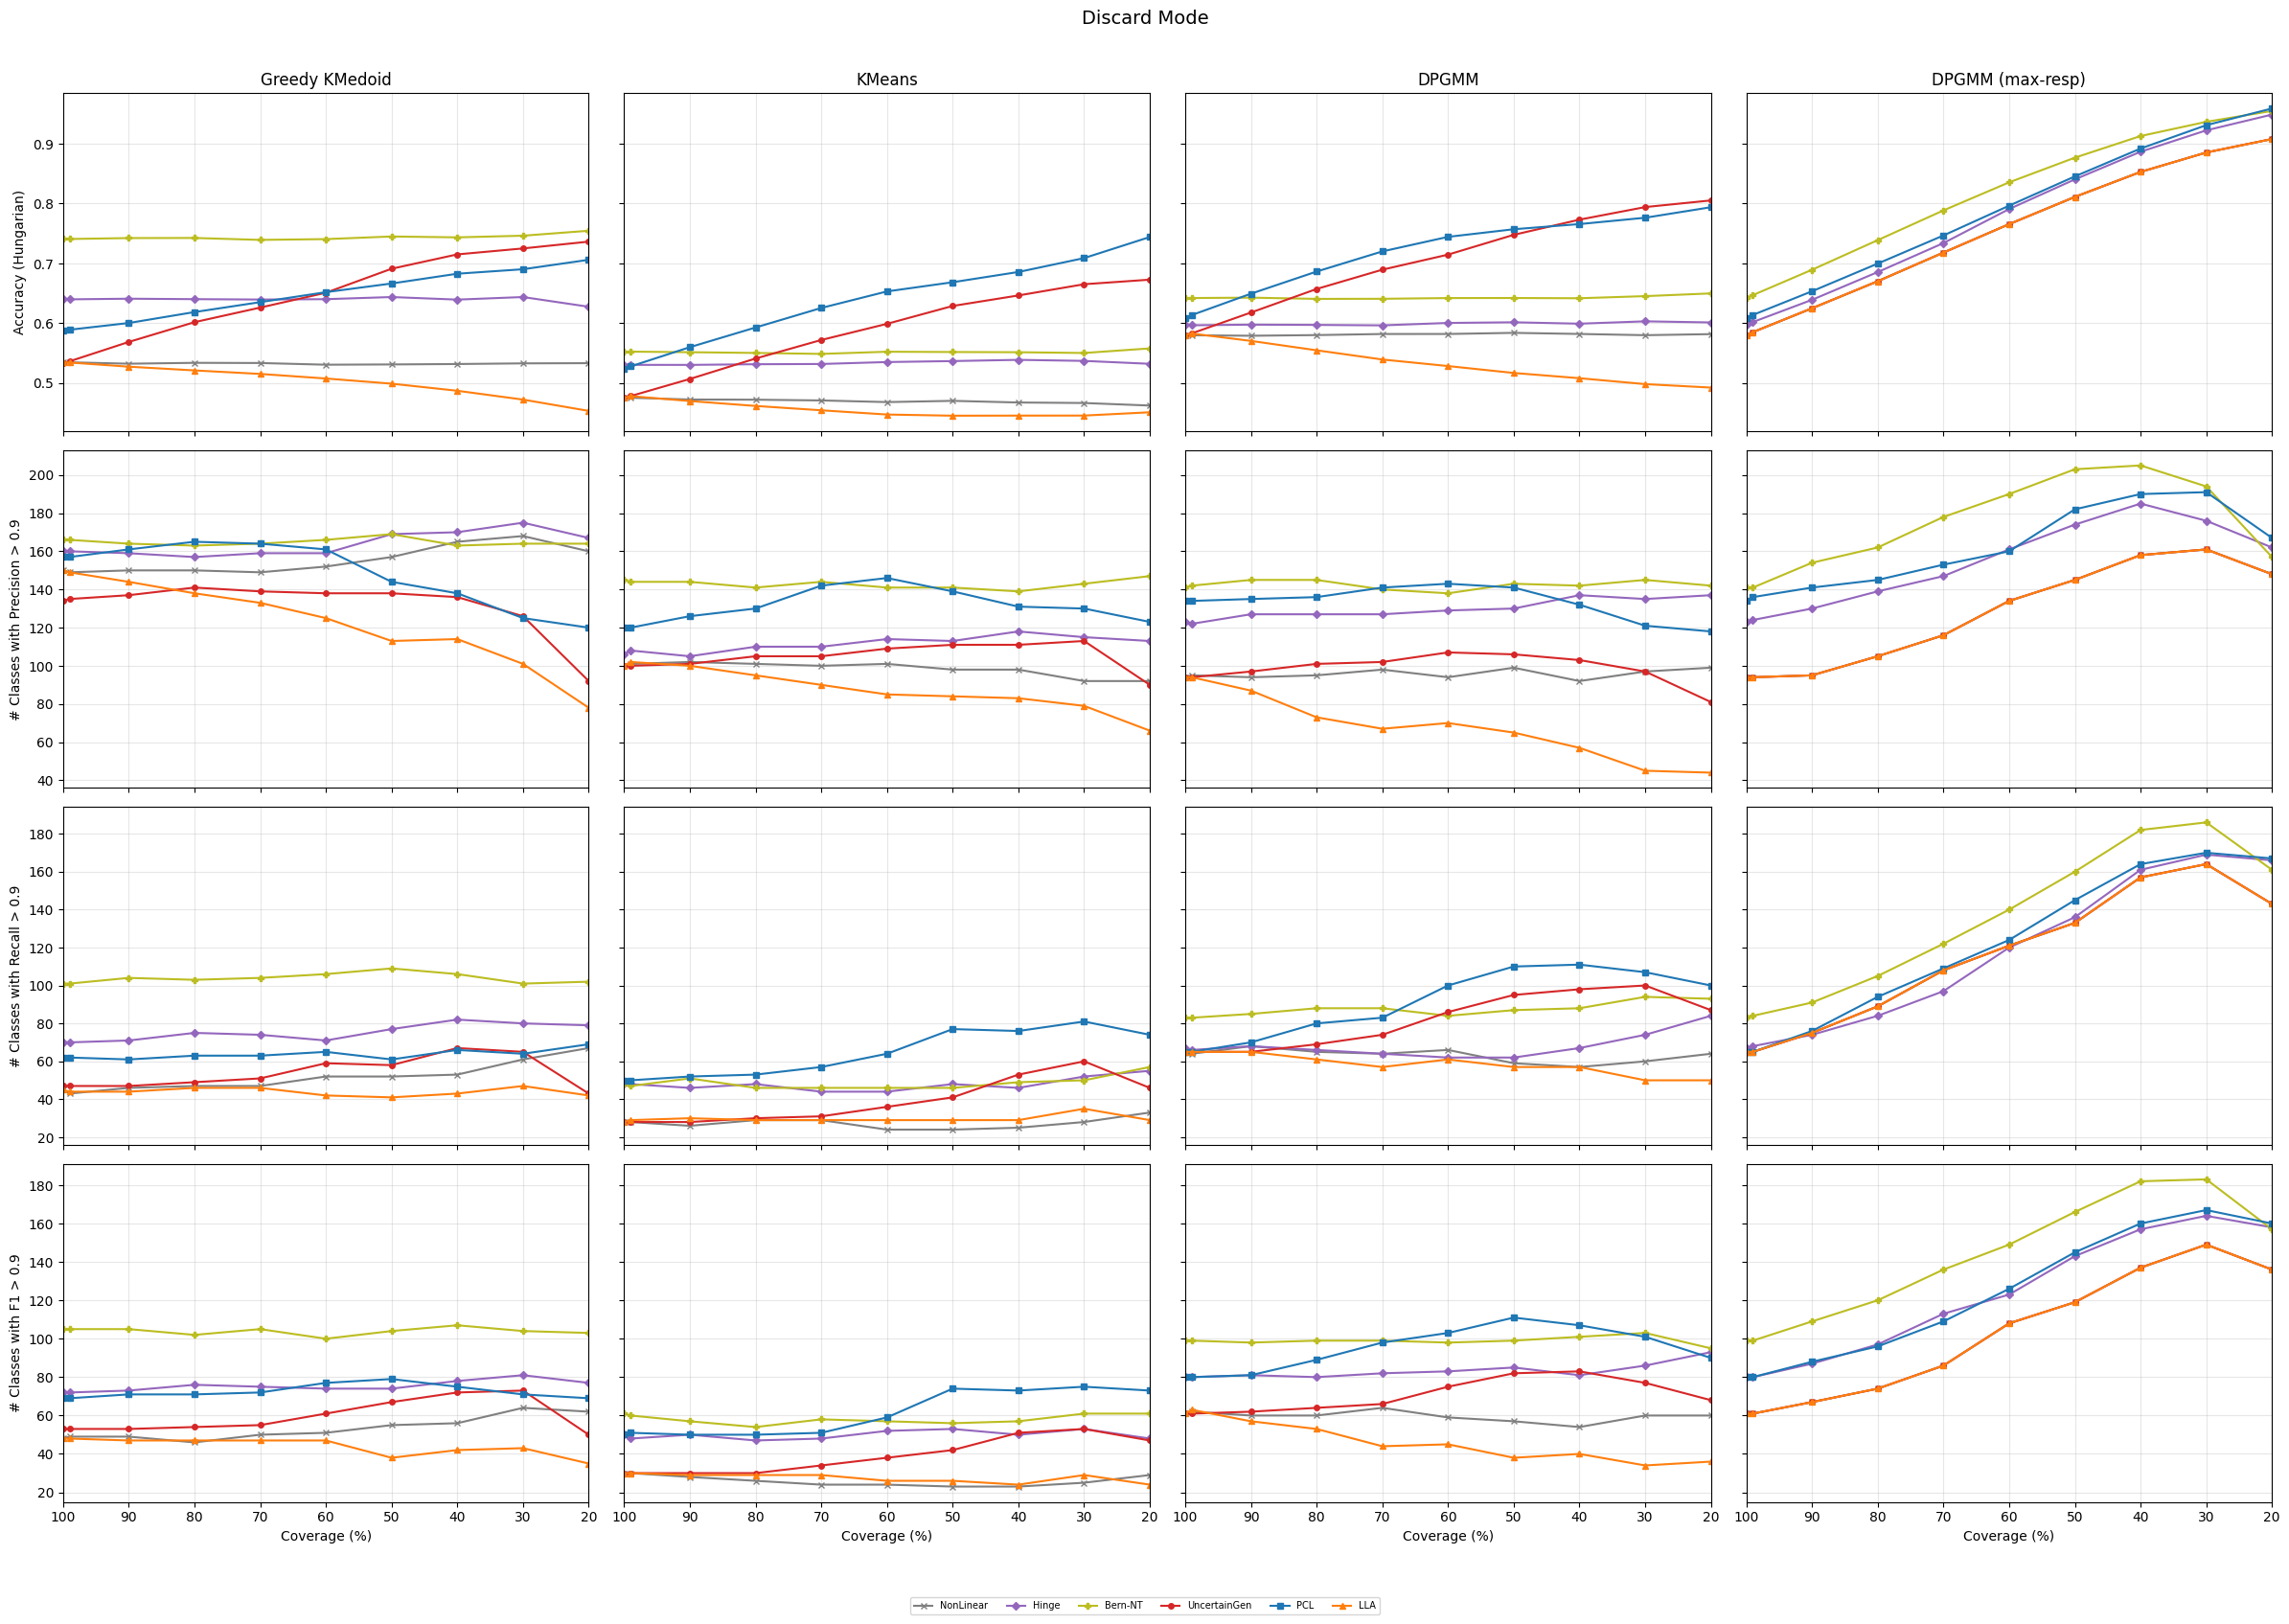

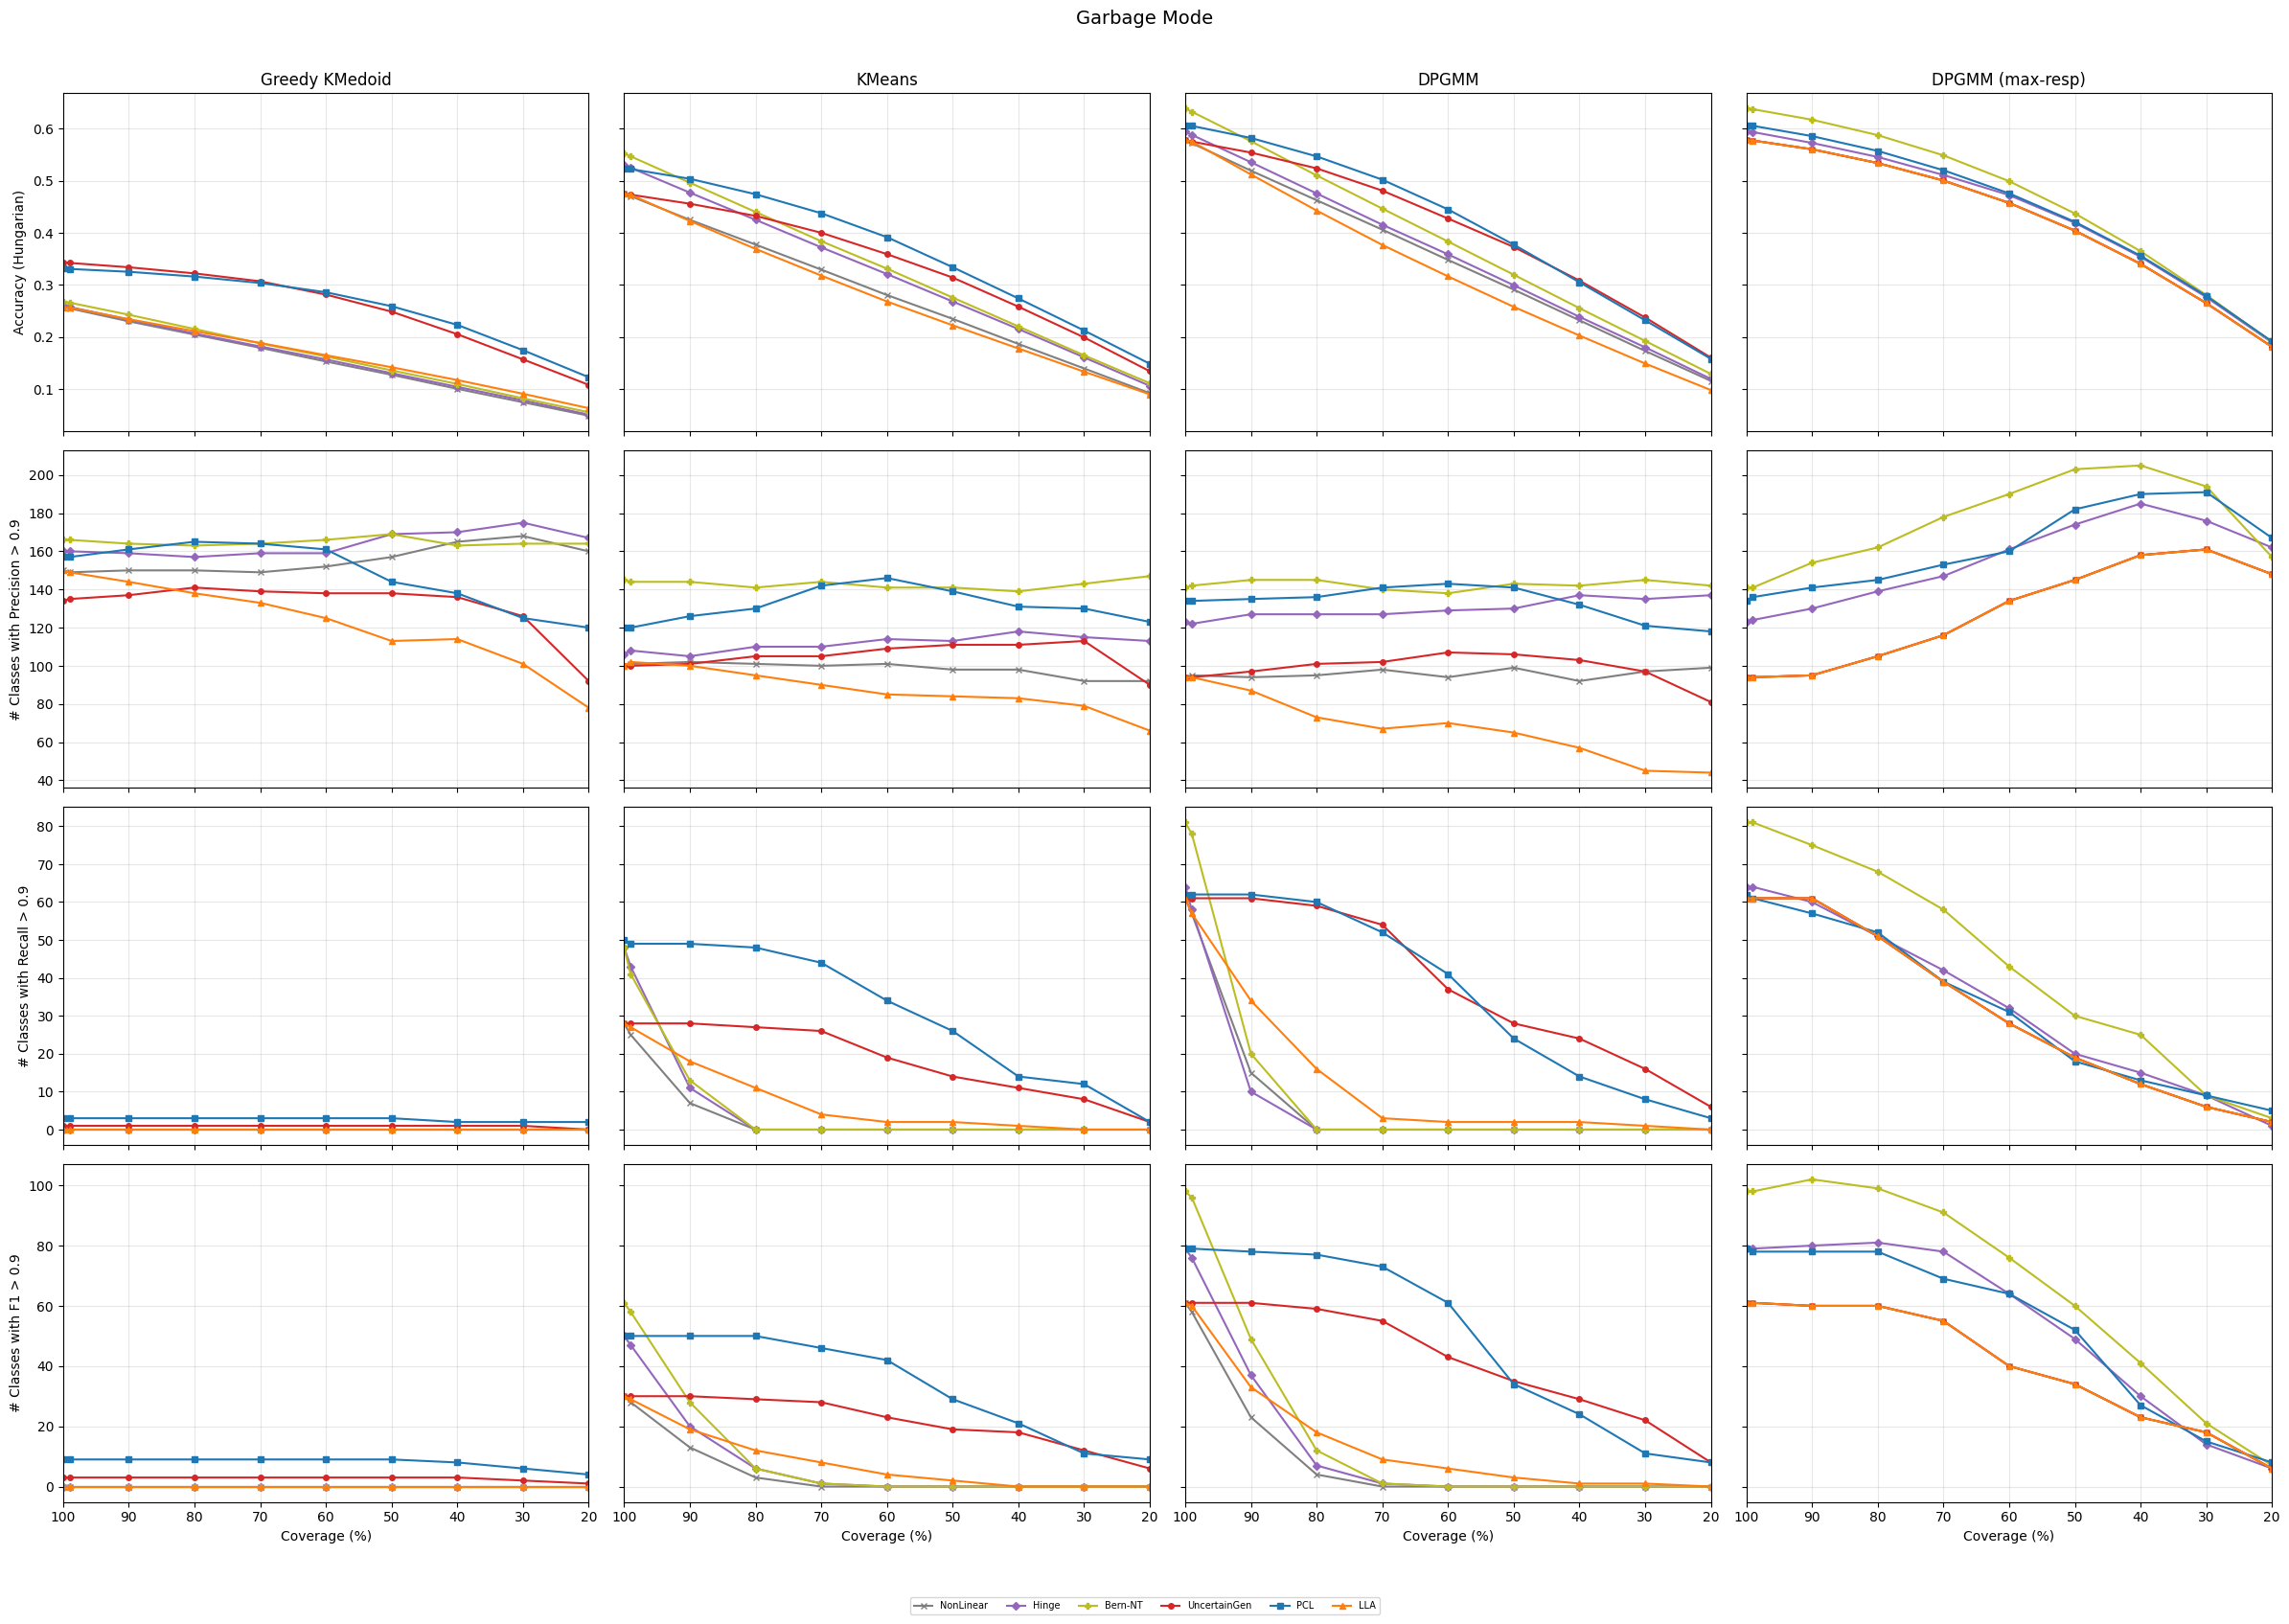

In [7]:
method_names = list(method_curves.keys())
METRICS = ['acc', 'precision', 'recall', 'f1']
METRIC_LABELS = {
    'acc': 'Accuracy (Hungarian)',
    'precision': '# Classes with Precision > 0.9',
    'recall': '# Classes with Recall > 0.9',
    'f1': '# Classes with F1 > 0.9',
}

n_methods = len(method_names)

# ── Discard mode ──
fig, axes = plt.subplots(len(METRICS), n_methods, figsize=(6 * n_methods, 4 * len(METRICS)),
                         sharex=True, sharey='row')
for col, method in enumerate(method_names):
    curves = method_curves[method]
    for row, metric_key in enumerate(METRICS):
        ax = axes[row, col]
        for m in MODEL_NAMES:
            covs = [r['coverage'] * 100 for r in curves[m]]
            vals = [r['discard'][metric_key] for r in curves[m]]
            ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                    color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                    markersize=4, linewidth=1.5)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(100, 20)
        if row == 0:
            ax.set_title(method, fontsize=12)
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric_key], fontsize=10)
        if row == len(METRICS) - 1:
            ax.set_xlabel('Coverage (%)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Discard Mode', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Garbage mode ──
fig, axes = plt.subplots(len(METRICS), n_methods, figsize=(6 * n_methods, 4 * len(METRICS)),
                         sharex=True, sharey='row')
for col, method in enumerate(method_names):
    curves = method_curves[method]
    for row, metric_key in enumerate(METRICS):
        ax = axes[row, col]
        for m in MODEL_NAMES:
            covs = [r['coverage'] * 100 for r in curves[m]]
            vals = [r['garbage'][metric_key] for r in curves[m]]
            ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                    color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                    markersize=4, linewidth=1.5)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(100, 20)
        if row == 0:
            ax.set_title(method, fontsize=12)
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric_key], fontsize=10)
        if row == len(METRICS) - 1:
            ax.set_xlabel('Coverage (%)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Garbage Mode', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# ── Summary Tables: Discard vs Garbage at key coverages ──
key_covs = [100, 80, 60, 40, 20]
cov_idx = {round(c * 100): i for i, c in enumerate(COVERAGES)}

for mode_key, mode_label in [('discard', 'DISCARD'), ('garbage', 'GARBAGE')]:
    print(f'\n{"="*100}')
    print(f'  MODE: {mode_label}')
    print(f'{"="*100}')
    for metric_key in METRICS:
        print(f'\n  {METRIC_LABELS[metric_key]}:')
        print(f'  {"Method":>18s}  {"Model":>12s}  ', end='')
        for c in key_covs:
            print(f'  {c:>5d}%', end='')
        print()
        print(f'  {"-"*75}')
        for method in method_names:
            curves = method_curves[method]
            for m in MODEL_NAMES:
                print(f'  {method:>18s}  {MODEL_LABELS[m]:>12s}  ', end='')
                for c in key_covs:
                    val = curves[m][cov_idx[c]][mode_key][metric_key]
                    print(f'  {val:6.3f}', end='')
                print()
            print()


  MODE: DISCARD

  Accuracy (Hungarian):
              Method         Model      100%     80%     60%     40%     20%
  ---------------------------------------------------------------------------
      Greedy KMedoid     NonLinear     0.534   0.534   0.531   0.532   0.533
      Greedy KMedoid         Hinge     0.640   0.640   0.640   0.639   0.627
      Greedy KMedoid       Bern-NT     0.741   0.742   0.741   0.743   0.755
      Greedy KMedoid  UncertainGen     0.532   0.602   0.651   0.715   0.736
      Greedy KMedoid           PCL     0.588   0.619   0.652   0.683   0.706
      Greedy KMedoid           LLA     0.534   0.521   0.507   0.487   0.453

              KMeans     NonLinear     0.475   0.472   0.468   0.467   0.462
              KMeans         Hinge     0.530   0.531   0.535   0.539   0.532
              KMeans       Bern-NT     0.552   0.550   0.552   0.551   0.558
              KMeans  UncertainGen     0.475   0.541   0.599   0.646   0.673
              KMeans           P

## 6. Rejected Samples Quality

Metrics computed on the **rejected** subset only (using their original cluster assignments).
If uncertainty is meaningful, rejected samples should have worse metrics,
and quality should degrade further as coverage increases (fewer rejected = only the worst remain).

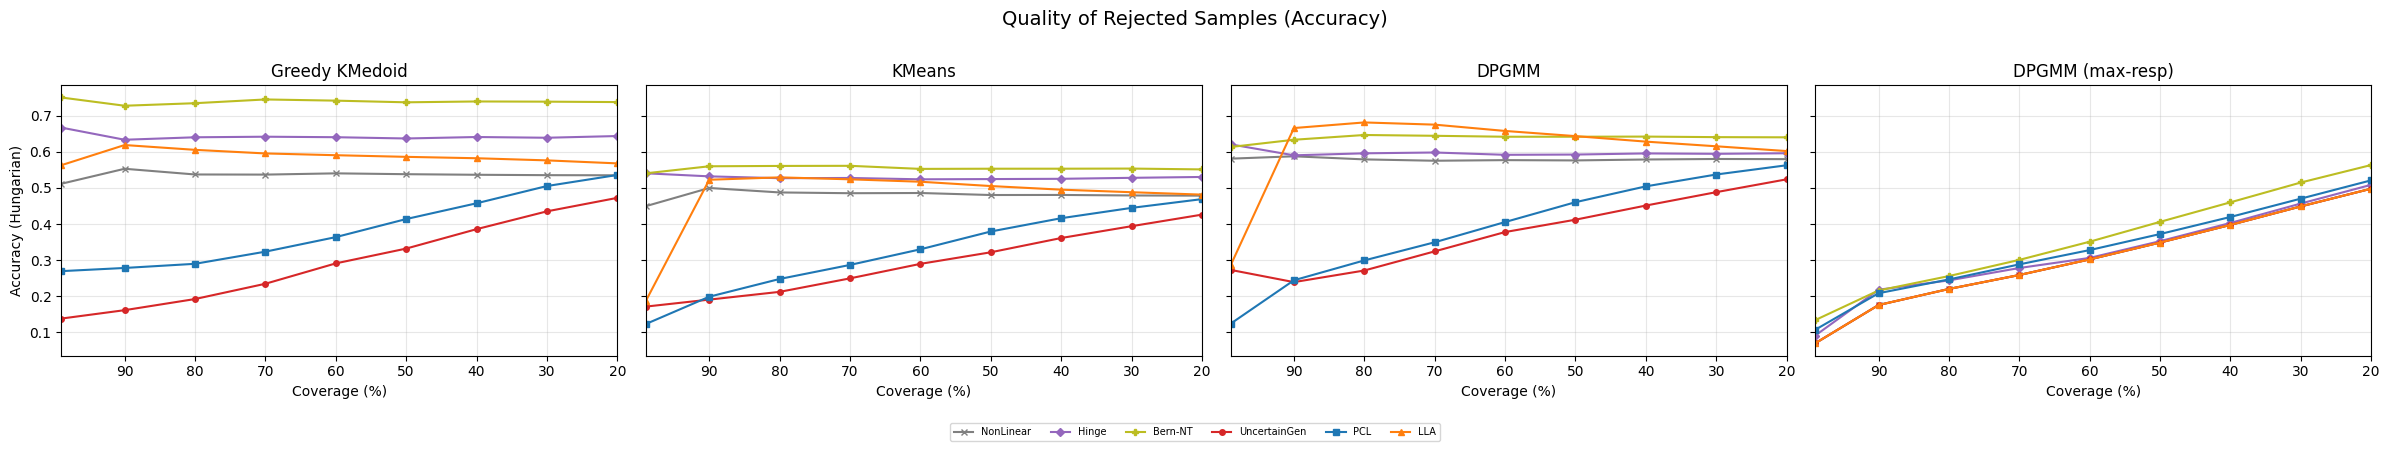

In [9]:
n_methods = len(method_names)
fig, axes = plt.subplots(1, n_methods, figsize=(6 * n_methods, 4),
                         sharex=True, sharey=True)

for col, method in enumerate(method_names):
    curves = method_curves[method]
    ax = axes[col]
    for m in MODEL_NAMES:
        # Skip 100% coverage (no rejected samples)
        covs = [r['coverage'] * 100 for r in curves[m] if r['coverage'] < 1.0]
        vals = [r['rejected']['acc'] for r in curves[m] if r['coverage'] < 1.0]
        ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                color=MODEL_COLORS[m], label=MODEL_LABELS[m], markersize=4)

    ax.grid(True, alpha=0.3)
    ax.set_xlim(99, 20)
    ax.set_title(method, fontsize=12)
    if col == 0:
        ax.set_ylabel(METRIC_LABELS['acc'], fontsize=10)
    ax.set_xlabel('Coverage (%)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=7,
           bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Quality of Rejected Samples (Accuracy)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()